In [1]:
"""
Stock Data Warehouse — Analytical Queries

Each query has three parts:
    1. Business question
    2. SQL (commented for clarity)
    3. Result (table or chart)
"""

import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
from db import get_engine

# pandas display settings for readable output
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', '{:,.4f}'.format)

# Build the database engine once, reuse for every query
engine = get_engine()

print("Notebook ready. Engine:", engine.url.database)

Notebook ready. Engine: stock_warehouse


In [2]:
# =============================================================================
# QUERY 1 — UNIVERSE OVERVIEW
# =============================================================================
# Question: How many companies do we track per sector, and what's our total
# universe size? This is the "what's in our database" check.

sql = """
SELECT
    s.sector_name,
    COUNT(c.ticker)   AS company_count
FROM sectors s
LEFT JOIN companies c ON c.sector_id = s.sector_id
GROUP BY s.sector_name
ORDER BY company_count DESC, s.sector_name;
"""

df = pd.read_sql(sql, engine)
print(df.to_string(index=False))
print(f"\nTotal companies: {df['company_count'].sum()}")

         sector_name  company_count
            Consumer             10
Energy & Industrials             10
          Financials             10
          Healthcare             10
          Technology             10

Total companies: 50


In [3]:
# =============================================================================
# QUERY 2 — DATA COVERAGE
# =============================================================================
# Question: What's the date range of our data, and do all stocks have full
# coverage? Thin tickers (few rows) may indicate recent IPOs or data gaps.

sql = """
SELECT
    ticker,
    MIN(date)         AS first_date,
    MAX(date)         AS last_date,
    COUNT(*)          AS trading_days
FROM daily_prices
GROUP BY ticker
ORDER BY trading_days ASC
LIMIT 10;
"""

df = pd.read_sql(sql, engine)
print("10 tickers with the LEAST history (potential issues):\n")
print(df.to_string(index=False))

10 tickers with the LEAST history (potential issues):

ticker first_date  last_date  trading_days
  AAPL 2021-04-19 2026-05-15          1276
   UNH 2021-04-19 2026-05-15          1276
  META 2021-04-19 2026-05-15          1276
  MSFT 2021-04-19 2026-05-15          1276
   MRK 2021-04-19 2026-05-15          1276
    HD 2021-04-19 2026-05-15          1276
   BAC 2021-04-19 2026-05-15          1276
   WFC 2021-04-19 2026-05-15          1276
  SBUX 2021-04-19 2026-05-15          1276
    DE 2021-04-19 2026-05-15          1276


In [4]:
# =============================================================================
# QUERY 3 — TOP PERFORMERS (5-YEAR CUMULATIVE RETURN)
# =============================================================================
# Question: Which stocks delivered the highest cumulative returns over the
# full data period? Uses adjusted close (accounts for splits/dividends).
#
# Cumulative return = (last_price / first_price) - 1
# We use a CTE (Common Table Expression) to compute first and last adj_close
# per ticker, then divide.

sql = """
WITH endpoints AS (
    SELECT
        ticker,
        FIRST_VALUE(adj_close) OVER (
            PARTITION BY ticker ORDER BY date
            ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING
        ) AS first_price,
        LAST_VALUE(adj_close)  OVER (
            PARTITION BY ticker ORDER BY date
            ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING
        ) AS last_price
    FROM daily_prices
)
SELECT
    e.ticker,
    c.company_name,
    s.sector_name,
    MIN(e.first_price)                                  AS first_price,
    MAX(e.last_price)                                   AS last_price,
    ROUND( (MAX(e.last_price) / MIN(e.first_price) - 1) * 100, 2 ) AS pct_return
FROM endpoints e
JOIN companies c ON c.ticker = e.ticker
JOIN sectors   s ON s.sector_id = c.sector_id
GROUP BY e.ticker, c.company_name, s.sector_name
ORDER BY pct_return DESC
LIMIT 10;
"""

df = pd.read_sql(sql, engine)
print("Top 10 performers over the full data period:\n")
print(df.to_string(index=False))

Top 10 performers over the full data period:

ticker                 company_name          sector_name  first_price  last_price  pct_return
  NVDA           NVIDIA Corporation           Technology      15.3231    225.3200  1,370.4600
   LLY        Eli Lilly and Company           Healthcare     180.1047  1,004.9200    457.9600
   AMD  Advanced Micro Devices Inc.           Technology      81.1100    424.1000    422.8700
    GE     General Electric Company Energy & Industrials      65.5324    281.5300    329.6000
   CAT             Caterpillar Inc. Energy & Industrials     211.5392    888.3100    319.9300
 GOOGL                Alphabet Inc.           Technology     113.5495    396.7800    249.4300
   XOM      Exxon Mobil Corporation Energy & Industrials      46.3204    157.9200    240.9300
    GS     Goldman Sachs Group Inc.           Financials     304.2594    948.4700    211.7300
   WMT                 Walmart Inc.             Consumer      43.5197    131.4500    202.0500
  COST Costco 

Sector performance over the data period:

         sector_name  n_companies  avg_return_pct  worst_return_pct  best_return_pct
          Technology           10        252.0800          -52.0300       1,370.4600
Energy & Industrials           10        127.5700          -31.1800         329.6000
          Financials           10        101.2000           33.1300         211.7300
          Healthcare           10         71.6200          -25.4900         457.9600
            Consumer           10         54.4400          -65.9200         202.0500


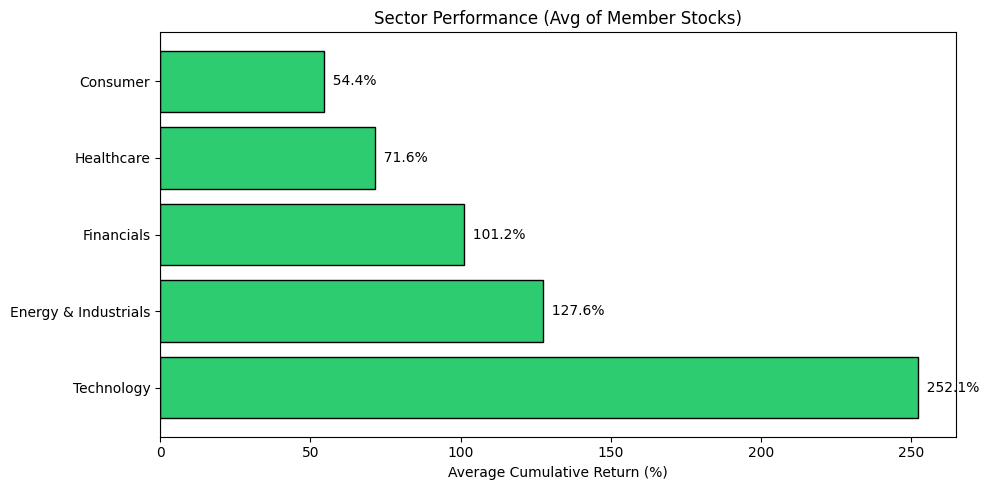

In [5]:
# =============================================================================
# QUERY 4 — SECTOR-LEVEL CUMULATIVE RETURNS
# =============================================================================
# Question: Which sectors as a whole performed best? Average the per-ticker
# returns within each sector.

sql = """
WITH endpoints AS (
    SELECT
        ticker,
        FIRST_VALUE(adj_close) OVER (
            PARTITION BY ticker ORDER BY date
            ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING
        ) AS first_price,
        LAST_VALUE(adj_close)  OVER (
            PARTITION BY ticker ORDER BY date
            ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING
        ) AS last_price
    FROM daily_prices
),
per_ticker AS (
    SELECT
        ticker,
        MIN(first_price)                              AS first_price,
        MAX(last_price)                               AS last_price,
        (MAX(last_price) / MIN(first_price) - 1) * 100 AS pct_return
    FROM endpoints
    GROUP BY ticker
)
SELECT
    s.sector_name,
    COUNT(pt.ticker)                          AS n_companies,
    ROUND(AVG(pt.pct_return)::numeric, 2)     AS avg_return_pct,
    ROUND(MIN(pt.pct_return)::numeric, 2)     AS worst_return_pct,
    ROUND(MAX(pt.pct_return)::numeric, 2)     AS best_return_pct
FROM per_ticker pt
JOIN companies c ON c.ticker = pt.ticker
JOIN sectors   s ON s.sector_id = c.sector_id
GROUP BY s.sector_name
ORDER BY avg_return_pct DESC;
"""

df = pd.read_sql(sql, engine)
print("Sector performance over the data period:\n")
print(df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in df['avg_return_pct']]
ax.barh(df['sector_name'], df['avg_return_pct'], color=colors, edgecolor='black')
ax.set_xlabel('Average Cumulative Return (%)')
ax.set_title('Sector Performance (Avg of Member Stocks)')
ax.axvline(0, color='black', linewidth=0.8)
for i, v in enumerate(df['avg_return_pct']):
    ax.text(v, i, f'  {v:.1f}%', va='center')
plt.tight_layout()
plt.show()

In [6]:
# =============================================================================
# QUERY 5 — VOLUME LEADERS
# =============================================================================
# Question: Which stocks trade the most shares per day on average?
# This is a liquidity proxy — high-volume stocks are easier to trade
# without moving the price.

sql = """
SELECT
    dp.ticker,
    c.company_name,
    s.sector_name,
    ROUND(AVG(dp.volume)::numeric, 0)   AS avg_daily_volume,
    ROUND(MAX(dp.volume)::numeric, 0)   AS max_daily_volume
FROM daily_prices dp
JOIN companies c ON c.ticker = dp.ticker
JOIN sectors   s ON s.sector_id = c.sector_id
GROUP BY dp.ticker, c.company_name, s.sector_name
ORDER BY avg_daily_volume DESC
LIMIT 15;
"""

df = pd.read_sql(sql, engine)
print("Top 15 stocks by average daily volume:\n")
print(df.to_string(index=False))

Top 15 stocks by average daily volume:

ticker                company_name          sector_name  avg_daily_volume   max_daily_volume
  NVDA          NVIDIA Corporation           Technology  381,397,365.0000 1,543,911,000.0000
  AAPL                  Apple Inc.           Technology   66,086,374.0000   318,679,900.0000
   AMD Advanced Micro Devices Inc.           Technology   60,486,007.0000   248,859,600.0000
  INTC           Intel Corporation           Technology   59,994,788.0000   523,908,000.0000
  AMZN             Amazon.com Inc.             Consumer   56,236,996.0000   272,662,000.0000
   BAC Bank of America Corporation           Financials   43,168,850.0000   218,403,300.0000
   PFE                 Pfizer Inc.           Healthcare   35,742,882.0000   349,996,500.0000
 GOOGL               Alphabet Inc.           Technology   32,112,409.0000   127,490,100.0000
  MSFT       Microsoft Corporation           Technology   26,025,533.0000   128,855,300.0000
  META         Meta Platforms 

In [7]:
# =============================================================================
# QUERY 6 — BIGGEST SINGLE-DAY MOVES
# =============================================================================
# Question: What were the most dramatic single-day price moves across all
# stocks in our universe? Could be earnings, crashes, takeover news, etc.

sql = """
WITH daily_returns AS (
    SELECT
        ticker,
        date,
        close,
        LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close,
        (close / NULLIF(LAG(close) OVER (PARTITION BY ticker ORDER BY date), 0) - 1) * 100
            AS pct_change
    FROM daily_prices
)
SELECT
    ticker,
    date,
    ROUND(prev_close::numeric, 2)    AS prev_close,
    ROUND(close::numeric, 2)         AS close,
    ROUND(pct_change::numeric, 2)    AS pct_change
FROM daily_returns
WHERE pct_change IS NOT NULL
ORDER BY ABS(pct_change) DESC
LIMIT 15;
"""

df = pd.read_sql(sql, engine)
print("Top 15 biggest single-day moves (up or down):\n")
print(df.to_string(index=False))

Top 15 biggest single-day moves (up or down):

ticker       date  prev_close    close  pct_change
  ORCL 2025-09-10    241.5100 328.3300     35.9500
  META 2022-02-03    323.0000 237.7600    -26.3900
  INTC 2024-08-02     29.0500  21.4800    -26.0600
  META 2022-10-27    129.8200  97.9400    -24.5600
  SBUX 2024-08-13     77.0300  95.9000     24.5000
  NVDA 2023-05-25     30.5400  37.9800     24.3700
   AMD 2025-04-09     78.2100  96.8400     23.8200
   AMD 2025-10-06    164.6700 203.7100     23.7100
  INTC 2026-04-24     66.7800  82.5400     23.6000
  META 2023-02-02    153.1200 188.7700     23.2800
  INTC 2025-09-18     24.9000  30.5700     22.7700
   UNH 2025-04-17    585.0400 454.1100    -22.3800
   FDX 2022-09-16    204.8700 161.0200    -21.4000
  META 2024-02-02    394.7800 474.9900     20.3200
   NKE 2024-06-28     94.1900  75.3700    -19.9800


In [9]:
# =============================================================================
# QUERY 7 — MOST VOLATILE STOCKS (DAILY RETURN STD DEV)
# =============================================================================
# Question: Which stocks have the highest daily-return volatility?
# Volatility is a basic risk measure — higher = riskier (and potentially
# higher-returning if you're on the right side of it).

sql = """
WITH daily_returns AS (
    SELECT
        ticker,
        date,
        (close / NULLIF(LAG(close) OVER (PARTITION BY ticker ORDER BY date), 0) - 1) AS daily_return
    FROM daily_prices
)
SELECT
    dr.ticker,
    c.company_name,
    s.sector_name,
    ROUND( (STDDEV(dr.daily_return) * SQRT(252) * 100)::numeric, 2 ) AS annualized_vol_pct,
    COUNT(dr.daily_return)  AS n_observations
FROM daily_returns dr
JOIN companies c ON c.ticker = dr.ticker
JOIN sectors   s ON s.sector_id = c.sector_id
WHERE dr.daily_return IS NOT NULL
GROUP BY dr.ticker, c.company_name, s.sector_name
ORDER BY annualized_vol_pct DESC
LIMIT 10;
"""

df = pd.read_sql(sql, engine)
print("Top 10 most volatile stocks (annualized):\n")
print(df.to_string(index=False))

Top 10 most volatile stocks (annualized):

ticker                company_name          sector_name  annualized_vol_pct  n_observations
   AMD Advanced Micro Devices Inc.           Technology             54.7400            1275
  NVDA          NVIDIA Corporation           Technology             51.4600            1275
  INTC           Intel Corporation           Technology             51.0900            1275
  META         Meta Platforms Inc.           Technology             43.7700            1275
  ORCL          Oracle Corporation           Technology             40.7600            1275
   CRM             Salesforce Inc.           Technology             36.3900            1275
    BA              Boeing Company Energy & Industrials             36.3200            1275
  ADBE                  Adobe Inc.           Technology             35.8000            1275
   NKE                   NIKE Inc.             Consumer             35.5300            1275
  AMZN             Amazon.com Inc.   

Monthly sector returns: 310 rows

     month          sector_name  avg_return_pct
2021-04-01             Consumer         -0.0900
2021-04-01 Energy & Industrials          1.0200
2021-04-01           Financials          1.8000
2021-04-01           Healthcare         -0.4800
2021-04-01           Technology         -1.1300
2021-05-01             Consumer          0.2200
2021-05-01 Energy & Industrials          3.9000
2021-05-01           Financials          4.5700
2021-05-01           Healthcare          3.1200
2021-05-01           Technology          0.7200
2021-06-01             Consumer          1.8900
2021-06-01 Energy & Industrials         -2.3500
2021-06-01           Financials         -1.1300
2021-06-01           Healthcare          2.5600
2021-06-01           Technology          8.4000


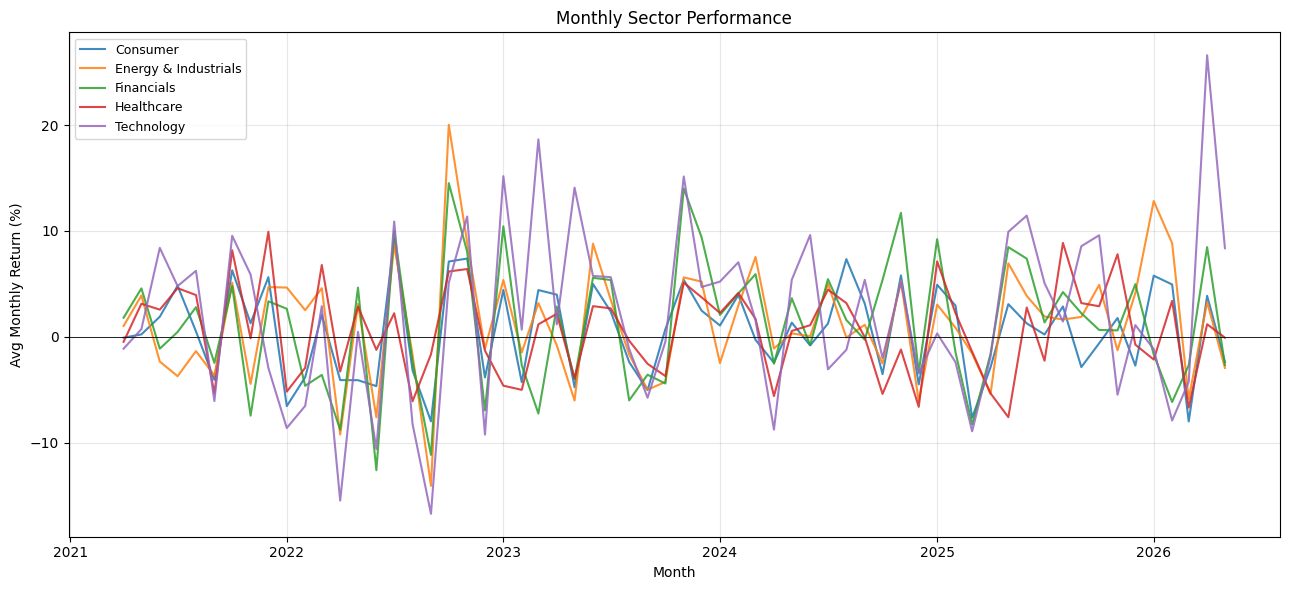

In [10]:
# =============================================================================
# QUERY 8 — MONTHLY SECTOR PERFORMANCE TIMELINE
# =============================================================================
# Question: How did each sector perform month-by-month? Aggregate daily
# returns to monthly, then average across each sector's stocks.

sql = """
WITH daily_returns AS (
    SELECT
        ticker,
        date,
        (close / NULLIF(LAG(close) OVER (PARTITION BY ticker ORDER BY date), 0) - 1)
            AS daily_return
    FROM daily_prices
),
monthly_per_ticker AS (
    SELECT
        ticker,
        DATE_TRUNC('month', date)::date         AS month,
        EXP(SUM(LN(1 + daily_return))) - 1      AS monthly_return
    FROM daily_returns
    WHERE daily_return IS NOT NULL
    GROUP BY ticker, DATE_TRUNC('month', date)
)
SELECT
    mp.month,
    s.sector_name,
    ROUND( (AVG(mp.monthly_return) * 100)::numeric, 2 ) AS avg_return_pct
FROM monthly_per_ticker mp
JOIN companies c ON c.ticker = mp.ticker
JOIN sectors   s ON s.sector_id = c.sector_id
GROUP BY mp.month, s.sector_name
ORDER BY mp.month, s.sector_name;
"""

df = pd.read_sql(sql, engine)
print(f"Monthly sector returns: {len(df)} rows\n")
print(df.head(15).to_string(index=False))

# Visualize as a line chart, one line per sector
pivot = df.pivot(index='month', columns='sector_name', values='avg_return_pct')

fig, ax = plt.subplots(figsize=(13, 6))
for sector in pivot.columns:
    ax.plot(pivot.index, pivot[sector], label=sector, linewidth=1.5, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_xlabel('Month')
ax.set_ylabel('Avg Monthly Return (%)')
ax.set_title('Monthly Sector Performance')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Rows: 1276, columns: ['date', 'close', 'ma_20', 'ma_50']

      date    close    ma_20    ma_50
2026-05-11 219.4400 204.6880 189.4960
2026-05-12 220.7800 205.9015 190.2620
2026-05-13 225.8300 207.2495 191.1776
2026-05-14 235.7400 209.1190 192.2316
2026-05-15 225.3200 210.3010 193.0712


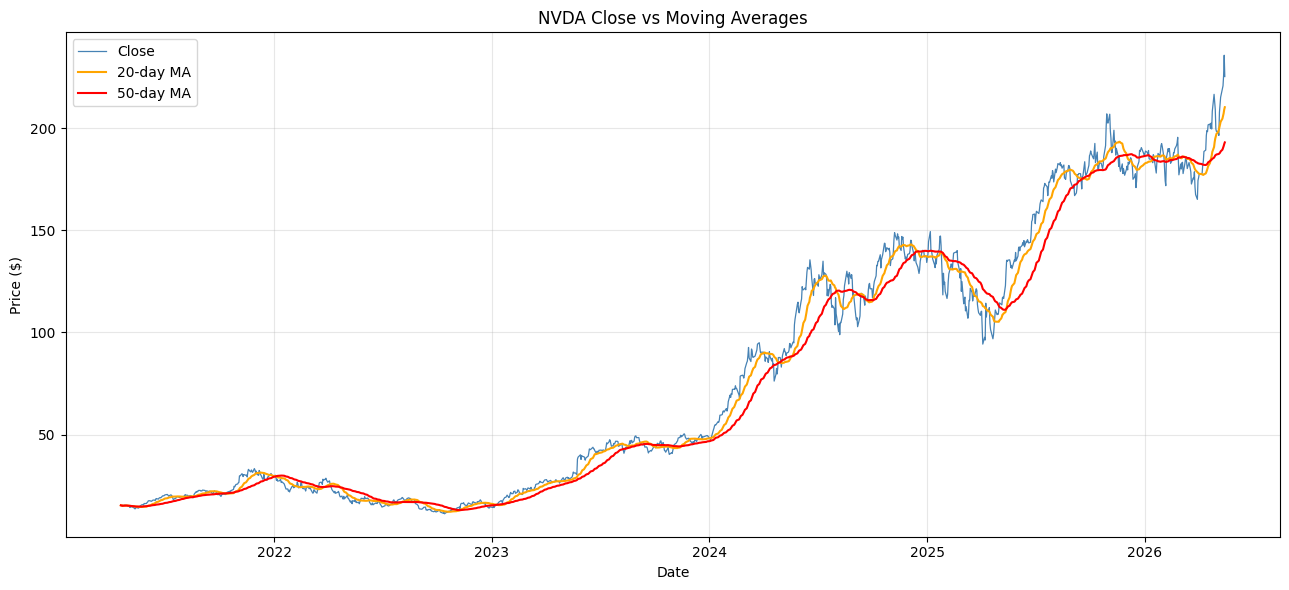

In [12]:
# =============================================================================
# QUERY 9 — 20-DAY MOVING AVERAGE FOR NVDA
# =============================================================================
# Question: Plot NVDA's price alongside its 20-day moving average — a
# classic technical indicator that smooths daily noise. Used as a trend
# filter in countless trading strategies.

sql = """
SELECT
    date,
    close,
    AVG(close) OVER (
        ORDER BY date
        ROWS BETWEEN 19 PRECEDING AND CURRENT ROW
    ) AS ma_20,
    AVG(close) OVER (
        ORDER BY date
        ROWS BETWEEN 49 PRECEDING AND CURRENT ROW
    ) AS ma_50
FROM daily_prices
WHERE ticker = 'NVDA'
ORDER BY date;
"""

df = pd.read_sql(sql, engine)
df['date'] = pd.to_datetime(df['date'])
print(f"Rows: {len(df)}, columns: {list(df.columns)}\n")
print(df.tail(5).to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(df['date'], df['close'], label='Close', linewidth=0.9, color='steelblue')
ax.plot(df['date'], df['ma_20'], label='20-day MA', linewidth=1.5, color='orange')
ax.plot(df['date'], df['ma_50'], label='50-day MA', linewidth=1.5, color='red')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.set_title('NVDA Close vs Moving Averages')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

15 worst max drawdowns:

ticker                company_name  max_drawdown_pct
  META         Meta Platforms Inc.          -76.7400
   NKE                   NIKE Inc.          -74.6400
  INTC           Intel Corporation          -68.7100
  ADBE                  Adobe Inc.          -67.2600
  NVDA          NVIDIA Corporation          -66.3400
   AMD Advanced Micro Devices Inc.          -65.4500
   UNH     UnitedHealth Group Inc.          -61.3900
   PFE                 Pfizer Inc.          -58.9600
   CRM             Salesforce Inc.          -58.6200
  ORCL          Oracle Corporation          -58.2500
   UPS  United Parcel Service Inc.          -57.9200
   CVS      CVS Health Corporation          -56.7900
  AMZN             Amazon.com Inc.          -56.1500
    BA              Boeing Company          -54.6700
   FDX           FedEx Corporation          -53.7000


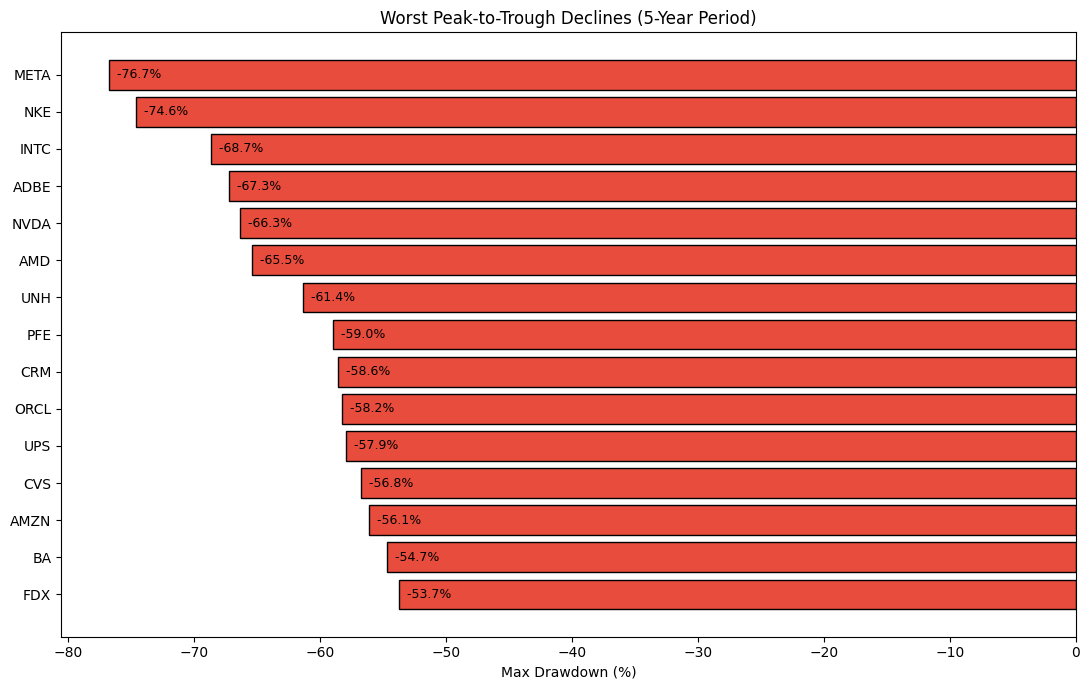

In [13]:
# =============================================================================
# QUERY 10 — MAXIMUM DRAWDOWN PER STOCK
# =============================================================================
# Question: For each stock, what's the worst peak-to-trough decline?
# Max drawdown is THE most important downside-risk metric in finance.
# A stock that returned 200% but dropped 80% along the way is very
# different from one that returned 150% with a max drawdown of 20%.

sql = """
WITH running_max AS (
    SELECT
        ticker,
        date,
        adj_close,
        MAX(adj_close) OVER (
            PARTITION BY ticker
            ORDER BY date
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS peak_so_far
    FROM daily_prices
),
drawdowns AS (
    SELECT
        ticker,
        date,
        adj_close,
        peak_so_far,
        (adj_close / peak_so_far - 1) AS drawdown
    FROM running_max
)
SELECT
    d.ticker,
    c.company_name,
    ROUND((MIN(d.drawdown) * 100)::numeric, 2) AS max_drawdown_pct
FROM drawdowns d
JOIN companies c ON c.ticker = d.ticker
GROUP BY d.ticker, c.company_name
ORDER BY max_drawdown_pct ASC
LIMIT 15;
"""

df = pd.read_sql(sql, engine)
print("15 worst max drawdowns:\n")
print(df.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(df['ticker'], df['max_drawdown_pct'], color='#e74c3c', edgecolor='black')
ax.set_xlabel('Max Drawdown (%)')
ax.set_title('Worst Peak-to-Trough Declines (5-Year Period)')
ax.axvline(0, color='black', linewidth=0.6)
for i, v in enumerate(df['max_drawdown_pct']):
    ax.text(v, i, f'  {v:.1f}%', va='center', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

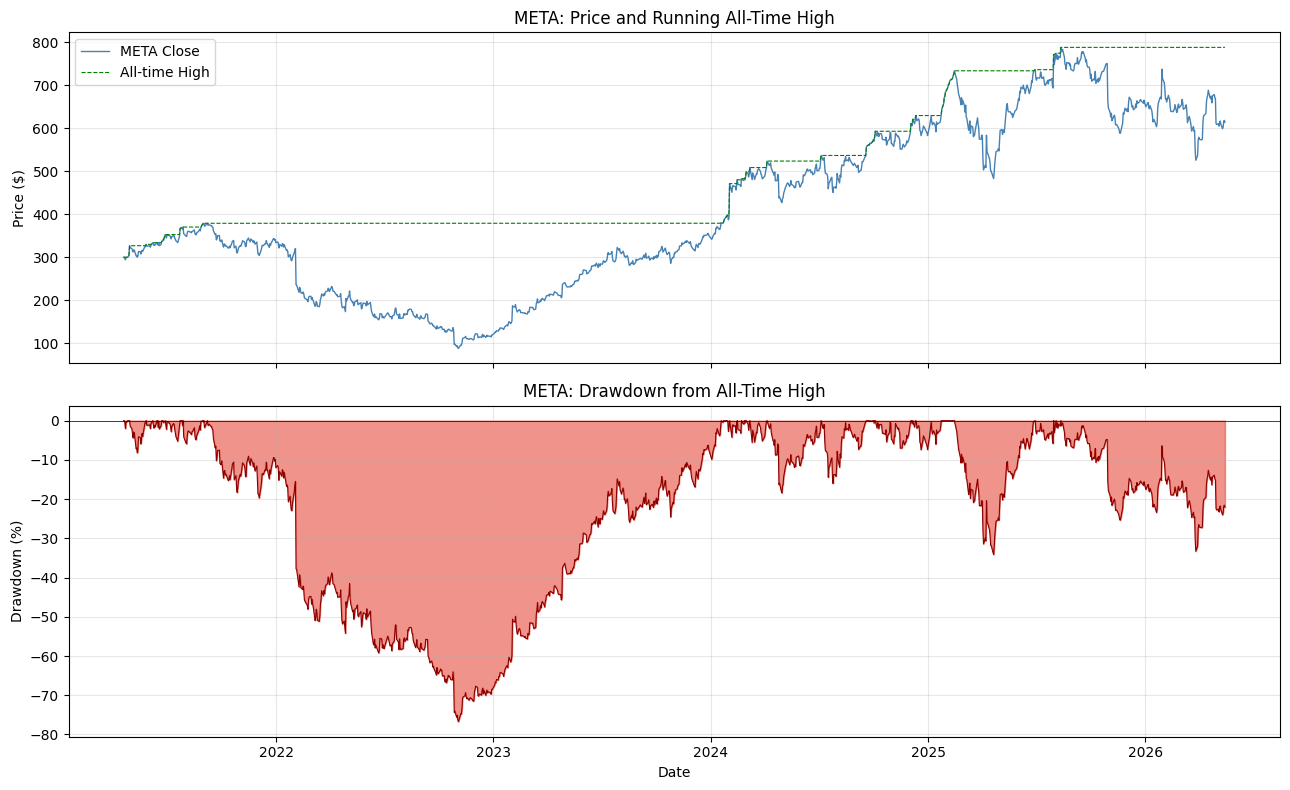

In [14]:
# =============================================================================
# QUERY 11 — DRAWDOWN CURVE FOR META
# =============================================================================
# Question: Visualize META's full drawdown curve over time. The chart
# shows how far it was below its rolling all-time high on each date —
# a much richer picture than a single "max drawdown" number.

sql = """
WITH running_max AS (
    SELECT
        date,
        adj_close,
        MAX(adj_close) OVER (
            ORDER BY date
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS peak_so_far
    FROM daily_prices
    WHERE ticker = 'META'
)
SELECT
    date,
    adj_close,
    peak_so_far,
    (adj_close / peak_so_far - 1) * 100 AS drawdown_pct
FROM running_max
ORDER BY date;
"""

df = pd.read_sql(sql, engine)
df['date'] = pd.to_datetime(df['date'])

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(df['date'], df['adj_close'], color='steelblue', linewidth=1.0, label='META Close')
axes[0].plot(df['date'], df['peak_so_far'], color='green', linewidth=0.8, linestyle='--', label='All-time High')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('META: Price and Running All-Time High')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].fill_between(df['date'], df['drawdown_pct'], 0, color='#e74c3c', alpha=0.6)
axes[1].plot(df['date'], df['drawdown_pct'], color='darkred', linewidth=0.8)
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_xlabel('Date')
axes[1].set_title('META: Drawdown from All-Time High')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# =============================================================================
# QUERY 12 — BEST AND WORST STOCK PER MONTH
# =============================================================================
# Question: For each month in our data, which stock had the best monthly
# return and which had the worst? Uses RANK() to find the extremes.

sql = """
WITH daily_returns AS (
    SELECT
        ticker,
        date,
        (close / NULLIF(LAG(close) OVER (PARTITION BY ticker ORDER BY date), 0) - 1)
            AS daily_return
    FROM daily_prices
),
monthly_returns AS (
    SELECT
        ticker,
        DATE_TRUNC('month', date)::date           AS month,
        EXP(SUM(LN(1 + daily_return))) - 1        AS monthly_return
    FROM daily_returns
    WHERE daily_return IS NOT NULL
    GROUP BY ticker, DATE_TRUNC('month', date)
),
ranked AS (
    SELECT
        month,
        ticker,
        monthly_return,
        RANK() OVER (PARTITION BY month ORDER BY monthly_return DESC) AS best_rank,
        RANK() OVER (PARTITION BY month ORDER BY monthly_return ASC)  AS worst_rank
    FROM monthly_returns
)
SELECT
    month,
    MAX(CASE WHEN best_rank = 1  THEN ticker END)                            AS best_ticker,
    ROUND((MAX(CASE WHEN best_rank = 1  THEN monthly_return END) * 100)::numeric, 2)  AS best_return_pct,
    MAX(CASE WHEN worst_rank = 1 THEN ticker END)                            AS worst_ticker,
    ROUND((MAX(CASE WHEN worst_rank = 1 THEN monthly_return END) * 100)::numeric, 2)  AS worst_return_pct
FROM ranked
GROUP BY month
ORDER BY month DESC
LIMIT 15;
"""

df = pd.read_sql(sql, engine)
print("Best & worst stock each month (most recent 15):\n")
print(df.to_string(index=False))

Best & worst stock each month (most recent 15):

     month best_ticker  best_return_pct worst_ticker  worst_return_pct
2026-05-01         AMD          19.6400          WFC          -10.7100
2026-04-01        INTC         114.0900          NKE          -16.0200
2026-03-01         XOM          11.2500           GE          -17.0900
2026-02-01         FDX          20.0900          AMD          -15.4300
2026-01-01         LMT          31.1300          CRM          -19.8600
2025-12-01         CRM          14.9100         INTC           -9.0200
2025-11-01         LLY          24.6400         ORCL          -23.1000
2025-10-01         AMD          58.3000         META          -11.7100
2025-09-01        INTC          37.7800          NKE           -9.8700
2025-08-01         UNH          24.1700         ORCL          -10.8900
2025-07-01         AMD          24.2500          UNH          -20.0100
2025-06-01        ORCL          32.0800          MCD           -6.9100
2025-05-01        NVDA      

Pairwise correlation of daily returns:

ticker   AAPL    AMD  GOOGL   META   MSFT   NVDA
ticker                                          
AAPL   1.0000 0.4620 0.5640 0.4680 0.5870 0.5000
AMD    0.4620 1.0000 0.4990 0.4430 0.4990 0.6730
GOOGL  0.5640 0.4990 1.0000 0.5410 0.5860 0.5120
META   0.4680 0.4430 0.5410 1.0000 0.5580 0.4970
MSFT   0.5870 0.4990 0.5860 0.5580 1.0000 0.6050
NVDA   0.5000 0.6730 0.5120 0.4970 0.6050 1.0000


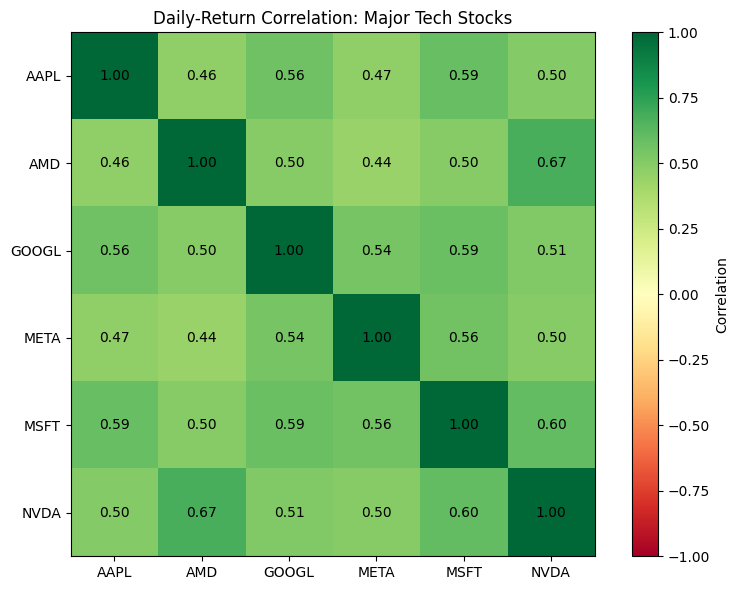

In [16]:
# =============================================================================
# QUERY 13 — PAIRWISE CORRELATION MATRIX
# =============================================================================
# Question: How correlated are the major tech stocks' daily returns?
# High correlation means they move together (diversification benefit
# is low). This is core portfolio construction math.

sql = """
WITH daily_returns AS (
    SELECT
        ticker,
        date,
        (close / NULLIF(LAG(close) OVER (PARTITION BY ticker ORDER BY date), 0) - 1)
            AS daily_return
    FROM daily_prices
    WHERE ticker IN ('AAPL','MSFT','GOOGL','META','NVDA','AMD')
)
SELECT
    date,
    ticker,
    daily_return
FROM daily_returns
WHERE daily_return IS NOT NULL
ORDER BY date, ticker;
"""

df = pd.read_sql(sql, engine)
returns = df.pivot(index='date', columns='ticker', values='daily_return')
corr_matrix = returns.corr()

print("Pairwise correlation of daily returns:\n")
print(corr_matrix.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticklabels(corr_matrix.columns)
plt.colorbar(im, ax=ax, label='Correlation')

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', color='black', fontsize=10)

ax.set_title('Daily-Return Correlation: Major Tech Stocks')
plt.tight_layout()
plt.show()

In [17]:
# =============================================================================
# QUERY 14 — DAYS SINCE 52-WEEK HIGH
# =============================================================================
# Question: For each stock, how many trading days has it been since its
# 52-week high? Stocks far from their 52w high are in technical downtrends;
# stocks near their highs are in uptrends. Used by momentum traders.

sql = """
WITH rolling_max AS (
    SELECT
        ticker,
        date,
        adj_close,
        MAX(adj_close) OVER (
            PARTITION BY ticker
            ORDER BY date
            ROWS BETWEEN 251 PRECEDING AND CURRENT ROW
        ) AS rolling_52w_high
    FROM daily_prices
),
recent AS (
    SELECT
        ticker,
        date,
        adj_close,
        rolling_52w_high,
        ROW_NUMBER() OVER (PARTITION BY ticker ORDER BY date DESC) AS rn
    FROM rolling_max
)
SELECT
    r.ticker,
    c.company_name,
    r.date                                            AS last_date,
    ROUND(r.adj_close::numeric, 2)                    AS current_price,
    ROUND(r.rolling_52w_high::numeric, 2)             AS high_52w,
    ROUND(((r.adj_close / r.rolling_52w_high - 1) * 100)::numeric, 2) AS pct_below_high
FROM recent r
JOIN companies c ON c.ticker = r.ticker
WHERE r.rn = 1
ORDER BY pct_below_high ASC
LIMIT 15;
"""

df = pd.read_sql(sql, engine)
print("15 stocks furthest below their 52-week high:\n")
print(df.to_string(index=False))

15 stocks furthest below their 52-week high:

ticker                company_name  last_date  current_price  high_52w  pct_below_high
   NKE                   NIKE Inc. 2026-05-15        41.8800   77.8100        -46.1800
  ADBE                  Adobe Inc. 2026-05-15       247.6000  420.6800        -41.1400
  ORCL          Oracle Corporation 2026-05-15       192.9500  325.7600        -40.7700
   CRM             Salesforce Inc. 2026-05-15       173.5100  288.9900        -39.9600
   ABT         Abbott Laboratories 2026-05-15        84.4700  135.3200        -37.5800
   DHR         Danaher Corporation 2026-05-15       161.9100  241.5400        -32.9700
   TMO    Thermo Fisher Scientific 2026-05-15       438.3400  638.8200        -31.3800
    HD             Home Depot Inc. 2026-05-15       297.5100  417.9100        -28.8100
   LMT Lockheed Martin Corporation 2026-05-15       516.0100  676.7000        -23.7500
   WFC       Wells Fargo & Company 2026-05-15        73.4200   95.3700        -23.02

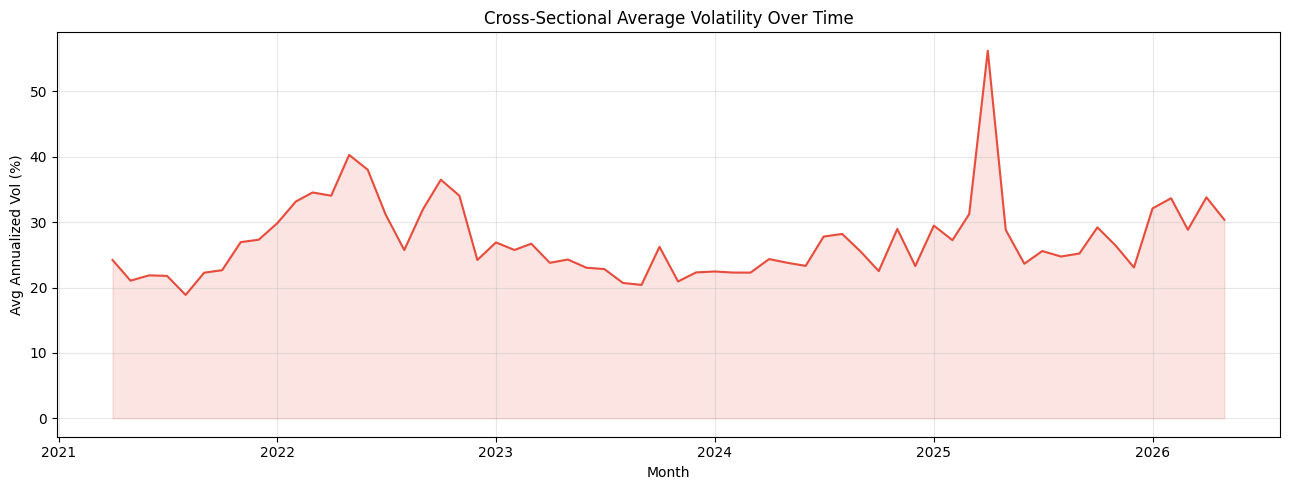


Highest-vol month: 2025-04-01 at 56.2%
Lowest-vol month:  2021-08-01 at 18.9%


In [18]:
# =============================================================================
# QUERY 15 — VOLATILITY OVER TIME (S&P-LIKE INDEX VIEW)
# =============================================================================
# Question: How did market-wide volatility evolve month by month?
# We average daily-return volatility across all 50 stocks each month
# — a poor man's VIX proxy.

sql = """
WITH daily_returns AS (
    SELECT
        ticker,
        date,
        (close / NULLIF(LAG(close) OVER (PARTITION BY ticker ORDER BY date), 0) - 1)
            AS daily_return
    FROM daily_prices
),
monthly_vol AS (
    SELECT
        DATE_TRUNC('month', date)::date  AS month,
        ticker,
        STDDEV(daily_return)             AS daily_vol
    FROM daily_returns
    WHERE daily_return IS NOT NULL
    GROUP BY DATE_TRUNC('month', date), ticker
)
SELECT
    month,
    ROUND( (AVG(daily_vol) * SQRT(252) * 100)::numeric, 2 ) AS avg_annualized_vol_pct
FROM monthly_vol
GROUP BY month
ORDER BY month;
"""

df = pd.read_sql(sql, engine)
df['month'] = pd.to_datetime(df['month'])

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df['month'], df['avg_annualized_vol_pct'], color='#e74c3c', linewidth=1.5)
ax.fill_between(df['month'], df['avg_annualized_vol_pct'], alpha=0.15, color='#e74c3c')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Annualized Vol (%)')
ax.set_title('Cross-Sectional Average Volatility Over Time')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nHighest-vol month: {df.loc[df['avg_annualized_vol_pct'].idxmax(), 'month'].date()} "
      f"at {df['avg_annualized_vol_pct'].max():.1f}%")
print(f"Lowest-vol month:  {df.loc[df['avg_annualized_vol_pct'].idxmin(), 'month'].date()} "
      f"at {df['avg_annualized_vol_pct'].min():.1f}%")

In [19]:
# =============================================================================
# QUERY 16 — DIVIDEND YIELD RANKINGS
# =============================================================================
# Question: Which stocks paid the most dividends relative to their price?
# Sums dividends per ticker over the data period, divides by current price.

sql = """
WITH dividend_totals AS (
    SELECT
        ticker,
        SUM(amount)                                       AS total_dividends,
        COUNT(*)                                          AS n_dividends
    FROM corporate_events
    WHERE event_type = 'dividend'
    GROUP BY ticker
),
latest_price AS (
    SELECT
        ticker,
        adj_close                                         AS current_price,
        date                                              AS as_of_date,
        ROW_NUMBER() OVER (PARTITION BY ticker ORDER BY date DESC) AS rn
    FROM daily_prices
)
SELECT
    dt.ticker,
    c.company_name,
    s.sector_name,
    dt.n_dividends,
    ROUND(dt.total_dividends::numeric, 2)                                          AS total_divs_paid,
    ROUND(lp.current_price::numeric, 2)                                            AS current_price,
    ROUND(((dt.total_dividends / lp.current_price) * 100)::numeric, 2)             AS trailing_yield_pct
FROM dividend_totals dt
JOIN latest_price lp ON lp.ticker = dt.ticker AND lp.rn = 1
JOIN companies     c ON c.ticker = dt.ticker
JOIN sectors       s ON s.sector_id = c.sector_id
ORDER BY trailing_yield_pct DESC
LIMIT 15;
"""

df = pd.read_sql(sql, engine)
print("Top 15 dividend payers (cumulative yield over data period):\n")
print(df.to_string(index=False))

Top 15 dividend payers (cumulative yield over data period):

ticker                company_name          sector_name  n_dividends  total_divs_paid  current_price  trailing_yield_pct
   PFE                 Pfizer Inc.           Healthcare           21           8.6700        25.3300             34.2300
   UPS  United Parcel Service Inc. Energy & Industrials           20          30.3400        98.9300             30.6700
   PEP                PepsiCo Inc.             Consumer           20          25.0700       149.1200             16.8100
   NKE                   NIKE Inc.             Consumer           20           7.0300        41.8800             16.7900
   CVX         Chevron Corporation Energy & Industrials           20          30.8800       191.1000             16.1600
  ABBV                 AbbVie Inc.           Healthcare           20          30.3800       210.3900             14.4400
    PG    Procter & Gamble Company             Consumer           21          20.2400       